# Post-Hoc Conformal Prediction on LLaVA-1.5-7B for Hallucination Detection

> **Runtime requirement:** T4 GPU (16 GB VRAM) — set via *Runtime → Change runtime type → T4 GPU*

This notebook implements **Split-Conformal Prediction** as a post-hoc wrapper around a frozen Vision-Language Model (LLaVA-1.5-7B) to detect hallucinations on the POPE adversarial benchmark. Rather than trusting the model's raw output, it wraps each answer in a statistically-guaranteed **prediction set** — `{Yes}`, `{No}`, or `{Yes, No}` — where a two-label set signals the model is uncertain enough that its answer should be treated as a potential hallucination.

| Step | Description |
|---|---|
| 1 | Environment setup |
| 2 | Data loading (POPE + COCO val2014) |
| 3 | Model init in 4-bit (bitsandbytes) |
| 4 | Heuristic uncertainty score extraction |
| 5 | Conformal calibration & threshold q̂ |
| 6 | Inference, evaluation & visualisation |
| 7 | Summary, interpretation & results artifact |

## Step 1 — Environment Setup

Installs all required packages. Versions are specified as compatible ranges rather than exact pins, since exact pins can go stale as Python/CUDA versions change on hosted runtimes (Colab, Kaggle) — the cell prints the exact versions actually installed at the end, which is what you should cite for reproducibility. Do not run an additional `pip install -U ...` later in the notebook, as this can upgrade past what's installed here and break compatibility between packages.

**After this cell finishes, restart the runtime** (`Runtime → Restart runtime`), then continue from Step 2.

In [4]:
!pip install -q --only-binary=:all: \
    "transformers>=4.44,<4.46" \
    "tokenizers>=0.20,<0.21" \
    "accelerate>=0.29" \
    "bitsandbytes>=0.43" \
    "torch>=2.6.0" \
    "torchvision>=0.21.0" \
    "numpy>=2.0" \
    datasets \
    Pillow \
    requests \
    tqdm \
    matplotlib \
    scipy

import transformers, tokenizers, accelerate, bitsandbytes, torch, numpy
print(f"transformers : {transformers.__version__}")
print(f"tokenizers   : {tokenizers.__version__}")
print(f"accelerate   : {accelerate.__version__}")
print(f"bitsandbytes : {bitsandbytes.__version__}")
print(f"torch        : {torch.__version__}")
print(f"numpy        : {numpy.__version__}")
print("\nAll packages installed (wheel-only, no source builds).")
print("Go to Runtime -> Restart Runtime, then re-run from Step 2.")

transformers : 4.45.2
tokenizers   : 0.20.3
accelerate   : 1.14.0
bitsandbytes : 0.50.2
torch        : 2.11.0+cu128
numpy        : 2.1.3

All packages installed (wheel-only, no source builds).
Go to Runtime -> Restart Runtime, then re-run from Step 2.


In [11]:
import os
os.makedirs("figures", exist_ok=True)

def save_fig(name, dpi=200):
    """Save the current matplotlib figure to figures/<name>.png before showing it."""
    plt.savefig(f"figures/{name}.png", dpi=dpi, bbox_inches="tight")
    print(f"Saved figures/{name}.png")

## Step 2 — Data Loading (POPE Benchmark)

**POPE** (Polling-based Object Probing Evaluation) is a standard benchmark for binary hallucination evaluation in VLMs. Each sample has:
- `image` → filename of a **COCO val2014** image (POPE's JSON gives the exact filename, not a numeric ID)
- `text` → the question, e.g. "Is there a `<object>` in the image?"
- `label` → `"yes"` or `"no"`

We use the **adversarial split** (hardest: negative objects chosen based on COCO co-occurrence statistics). We use the full 3,000-sample split: **1,000 for calibration, 2,000 for test** (a large test set keeps evaluation variance low).

  Total POPE adversarial samples: 3000
  Calibration set : 1000 samples
  Test set        : 2000 samples

Sample question : Is there a dining table in the image?
Ground-truth    : no
Saved figures/sample_image.png


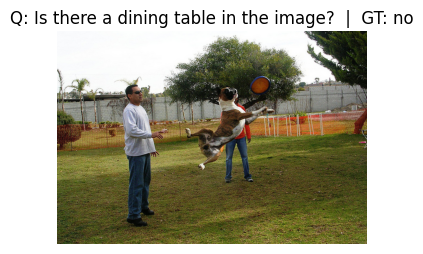

In [12]:
import json
import os
import random
import numpy as np
import torch
import requests
from io import BytesIO
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# ── reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── download POPE adversarial split (most challenging) ────────
POPE_URL = (
    "https://raw.githubusercontent.com/AoiDragon/POPE/main/"
    "output/coco/coco_pope_adversarial.json"
)

print("Downloading POPE annotations ...")
resp = requests.get(POPE_URL, timeout=60)
resp.raise_for_status()
pope_raw = [json.loads(line) for line in resp.text.strip().split("\n")]
print(f"  Total POPE adversarial samples: {len(pope_raw)}")

# ── use the full set ────────────────────────────
random.shuffle(pope_raw)

# ── calibration / test split ──────────────────────────────────
N_CALIB = 1000   # Used to fit a highly stable conformal threshold
N_TEST  = 2000   # Held-out for evaluation (large test set = low variance)

assert len(pope_raw) >= N_CALIB + N_TEST, (
    f"Expected at least {N_CALIB + N_TEST} POPE samples, got {len(pope_raw)}. "
    "Check the download above before proceeding — do not continue with a "
    "truncated split."
)

calib_data = pope_raw[:N_CALIB]
test_data  = pope_raw[N_CALIB:N_CALIB + N_TEST]

print(f"  Calibration set : {len(calib_data)} samples")
print(f"  Test set        : {len(test_data)} samples")
assert len(calib_data) == N_CALIB and len(test_data) == N_TEST, \
    "Split sizes don't match the configured N_CALIB/N_TEST — stop and investigate."

# ── helper: fetch a COCO val2014 image from official CDN ──────
# POPE annotations reference COCO val2014, not val2017.
COCO_BASE_URL = "http://images.cocodataset.org/val2014/"

IMAGE_LOAD_STATS = {"success": 0, "failed": 0}

def load_coco_image(image_filename: str) -> Image.Image:
    """
    Downloads a COCO val2014 image by its filename.
    Returns a PIL Image in RGB mode.
    Falls back to a blank grey image on network errors so
    the notebook can still demonstrate the pipeline, and
    records the failure in IMAGE_LOAD_STATS.
    """
    url = COCO_BASE_URL + image_filename

    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        IMAGE_LOAD_STATS["success"] += 1
        return img
    except Exception as e:
        IMAGE_LOAD_STATS["failed"] += 1
        print(f"    Could not load image {image_filename}: {e}  -> using placeholder")
        return Image.new("RGB", (336, 336), color=(128, 128, 128))

# ── quick sanity-check: display one sample ────────────────────
sample = calib_data[0]
print(f"\nSample question : {sample['text']}")
print(f"Ground-truth    : {sample['label']}")

img = load_coco_image(sample["image"])
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Q: {sample['text']}  |  GT: {sample['label']}")
plt.axis("off")
save_fig("sample_image")
plt.show()


## Step 3 — Model Initialisation (LLaVA-1.5-7B in 4-bit)

LLaVA-1.5-7B has ~7 billion parameters. In full fp16 that is ~14 GB — right at the T4 limit. **4-bit NF4 quantisation** (bitsandbytes) compresses linear weights to ~3.5 GB, freeing ~10 GB for activations and the vision tower.

Key `BitsAndBytesConfig` settings:
| Setting | Value | Reason |
|---|---|---|
| `load_in_4bit` | `True` | Enable NF4 weight compression |
| `bnb_4bit_use_double_quant` | `True` | Nested quantisation for slightly higher accuracy |
| `bnb_4bit_quant_type` | `"nf4"` | NormalFloat4 — best quality/size trade-off for LLMs |
| `bnb_4bit_compute_dtype` | `bfloat16` | Up-cast for matrix multiplications to preserve numerical range |

In [3]:
import bitsandbytes, accelerate, transformers, tokenizers, torch
print(f"transformers : {transformers.__version__}")
print(f"tokenizers   : {tokenizers.__version__}")
print(f"accelerate   : {accelerate.__version__}")
print(f"bitsandbytes : {bitsandbytes.__version__}")
print(f"torch        : {torch.__version__}")

transformers : 4.45.2
tokenizers   : 0.20.3
accelerate   : 1.14.0
bitsandbytes : 0.50.2
torch        : 2.11.0+cu128


In [4]:
import torch
from transformers import (
    LlavaForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)

# defensive re-seed in case this cell is the first one run after a
# runtime restart (SEED must match the value used in Step 2)
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_ID = "llava-hf/llava-1.5-7b-hf"

# ── 4-bit quantisation config ─────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,        # double-quant reduces memory further
    bnb_4bit_quant_type="nf4",             # NormalFloat4 — best quality/size trade-off
    bnb_4bit_compute_dtype=torch.bfloat16, # bf16 compute avoids fp16 overflow
)

print(f"Loading processor from {MODEL_ID} ...")
processor = AutoProcessor.from_pretrained(MODEL_ID)

print(f"Loading model in 4-bit from {MODEL_ID} ...")
print("  (This may take 3-5 minutes on the first run while weights are downloaded.)")

model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",          # bitsandbytes places layers on GPU automatically
    low_cpu_mem_usage=True,     # stream weights to GPU rather than loading to RAM first
)
model.eval()                    # we never train — freeze all gradients

print("\nModel loaded successfully!")
print(f"   Device map : {model.hf_device_map}")

# ── confirm VRAM usage ────────────────────────────────────────
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved  = torch.cuda.memory_reserved()  / 1e9
    print(f"   VRAM allocated : {allocated:.2f} GB")
    print(f"   VRAM reserved  : {reserved:.2f} GB")


Loading processor from llava-hf/llava-1.5-7b-hf ...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


Model loaded successfully!
   Device map : {'': 0}
   VRAM allocated : 4.09 GB
   VRAM reserved  : 4.27 GB


## Step 4 — Extracting Heuristic Uncertainty Scores

For a binary VQA question, rather than greedily decoding the full answer we:

1. Run a **single forward pass** — no autoregressive generation loop.
2. Grab the logit vector at position `-1` (the *next-token* distribution).
3. Slice out only `logit("Yes")` and `logit("No")`.
4. Apply a **2-class softmax** to get a binary probability.
5. Define the **non-conformity score**:

$$s(x, y) = 1 - \hat{p}(y \mid x)$$

where $y$ is the **true** label. A large score means the model is uncertain (or wrong) about the correct class.

**Prompt template** (LLaVA-1.5 instruction format):
```
USER: <image>
<question>
Answer with only 'Yes' or 'No'.
ASSISTANT:
```

In [5]:
from PIL import Image


In [6]:
import torch.nn.functional as F

# ── look up the token IDs for "Yes" and "No" ─────────────────
# tokenize WITHOUT a leading space (the model puts "Yes"/"No"
# right after "ASSISTANT:" with no space in its vocabulary)
YES_TOKEN_ID = processor.tokenizer.encode("Yes", add_special_tokens=False)[0]
NO_TOKEN_ID  = processor.tokenizer.encode("No",  add_special_tokens=False)[0]

print(f"Token ID for 'Yes' : {YES_TOKEN_ID}")
print(f"Token ID for 'No'  : {NO_TOKEN_ID}")


_yes_decoded = processor.tokenizer.decode([YES_TOKEN_ID]).strip()
_no_decoded  = processor.tokenizer.decode([NO_TOKEN_ID]).strip()
assert _yes_decoded.lower() == "yes", (
    f"YES_TOKEN_ID={YES_TOKEN_ID} decodes to {_yes_decoded!r}, not 'Yes' — "
    "tokenizer/vocab mismatch, stop and investigate before running calibration."
)
assert _no_decoded.lower() == "no", (
    f"NO_TOKEN_ID={NO_TOKEN_ID} decodes to {_no_decoded!r}, not 'No' — "
    "tokenizer/vocab mismatch, stop and investigate before running calibration."
)
assert YES_TOKEN_ID != NO_TOKEN_ID, "Yes/No token IDs must be distinct."
print("Token ID round-trip check passed.")


def build_prompt(question: str) -> str:
    """
    Wraps a raw POPE question in the LLaVA-1.5 instruction template.
    The processor will replace <image> with the visual embeddings.
    """
    return (
        f"USER: <image>\n"
        f"{question}\n"
        f"Answer with only 'Yes' or 'No'.\n"
        f"ASSISTANT:"
    )


@torch.inference_mode()                   # disable grad tracking -> saves ~30% VRAM
def get_yes_no_probs(image: Image.Image, question: str) -> dict:
    """
    Run one forward pass of LLaVA and return a probability
    distribution over {'Yes', 'No'}.

    Parameters
    ----------
    image    : PIL.Image  - the visual context
    question : str        - the raw POPE question string

    Returns
    -------
    dict with keys:
        'p_yes'      : float  - P(Yes | image, question)
        'p_no'       : float  - P(No  | image, question)
        'prediction' : str    - 'yes' if p_yes > p_no else 'no'
    """
    prompt = build_prompt(question)

    # processor handles pixel normalisation and tokenisation jointly
    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt",
    ).to(model.device, torch.float16)    # cast pixel_values to fp16 for the vision tower

    # ── single forward pass ───────────────────────────────────
    outputs = model(**inputs)

    # outputs.logits shape: (batch=1, seq_len, vocab_size)
    # We want the last token position, which predicts the NEXT token
    next_token_logits = outputs.logits[0, -1, :]  # shape: (vocab_size,)

    # ── extract the two relevant logits ──────────────────────
    binary_logits = torch.stack([
        next_token_logits[YES_TOKEN_ID],
        next_token_logits[NO_TOKEN_ID],
    ])                                             # shape: (2,)

    # ── 2-class softmax ───────────────────────────────────────
    binary_probs = F.softmax(binary_logits.float(), dim=0)

    p_yes = binary_probs[0].item()
    p_no  = binary_probs[1].item()

    return {
        "p_yes"      : p_yes,
        "p_no"       : p_no,
        "prediction" : "yes" if p_yes > p_no else "no",
    }


def nonconformity_score(probs: dict, true_label: str) -> float:
    """s(x, y) = 1 - p_hat(y | x)"""
    p_true = probs["p_yes"] if true_label.lower() == "yes" else probs["p_no"]
    return 1.0 - p_true


# ── smoke test on a real, already-loaded sample (calib_data[0]) ──
_smoke_sample = calib_data[0]
_smoke_img    = load_coco_image(_smoke_sample["image"])
_smoke_probs  = get_yes_no_probs(_smoke_img, _smoke_sample["text"])
_smoke_score  = nonconformity_score(_smoke_probs, _smoke_sample["label"])

print(f"\nSmoke test:")
print(f"  Question    : {_smoke_sample['text']}")
print(f"  True label  : {_smoke_sample['label']}")
print(f"  P(Yes)      : {_smoke_probs['p_yes']:.4f}")
print(f"  P(No)       : {_smoke_probs['p_no']:.4f}")
print(f"  Prediction  : {_smoke_probs['prediction']}")
print(f"  NC score    : {_smoke_score:.4f}")
assert abs(_smoke_probs["p_yes"] + _smoke_probs["p_no"] - 1.0) < 1e-4, \
    "P(Yes) + P(No) should sum to 1.0 under the 2-class softmax."


Token ID for 'Yes' : 3869
Token ID for 'No'  : 1939
Token ID round-trip check passed.


Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)



Smoke test:
  Question    : Is there a dining table in the image?
  True label  : no
  P(Yes)      : 0.1037
  P(No)       : 0.8963
  Prediction  : no
  NC score    : 0.1037


## Step 5 — Conformal Calibration (Split-Conformal Prediction)

### Theoretical Background

**Goal:** Given a target *miscoverage* rate $\alpha \in (0,1)$, construct prediction sets $C(x)$ such that for a new test point $(x^*, y^*)$:

$$P\bigl(y^* \in C(x^*)\bigr) \geq 1 - \alpha$$

This **marginal coverage guarantee** holds without any distributional assumptions beyond *exchangeability* — satisfied when calibration and test data are i.i.d.

### Non-Conformity Score

$$s(x_i, y_i) = 1 - \hat{p}(y_i \mid x_i)$$

Higher score → less conforming (model is surprised by the correct answer).

### Computing the Conformal Quantile $\hat{q}$

Let $s_1, \dots, s_n$ be the calibration non-conformity scores. The **finite-sample corrected quantile** is:

$$\hat{q} = \text{Quantile}\!\left(\{s_1, \dots, s_n, +\infty\},\; \frac{\lceil (n+1)(1-\alpha) \rceil}{n}\right)$$

The $+\infty$ appended accounts for the possibility that the test point is a genuine outlier — it inflates the quantile just enough to maintain the guarantee exactly (Vovk et al., 2005).

### Building the Prediction Set

$$C(x^*) = \bigl\{y \in \{\text{Yes}, \text{No}\} : s(x^*, y) \leq \hat{q}\bigr\} = \bigl\{y : \hat{p}(y \mid x^*) \geq 1 - \hat{q}\bigr\}$$

| Prediction set | Interpretation |
|---|---|
| `{Yes}` | Model is confidently Yes |
| `{No}` | Model is confidently No |
| `{Yes, No}` | Model is uncertain → **potential hallucination flag** |
| `{}` | Extremely rare (only if $\hat{q} < 0$) |

> **Note:** this loop calls a 7B-parameter model ~1,000 times, which can take a long time on a T4. The cell below checkpoints progress every 50 samples to `calib_checkpoint.json`, so if the runtime disconnects partway through, re-running the cell resumes from the last checkpoint instead of starting over.

Resuming calibration from checkpoint: 1000/1000 samples already scored.


Calibrating: 100%|##########| 1000/1000 [00:00<?, ?it/s]


Calibration score statistics (n=1000):
  Mean  : 0.2757
  Median: 0.2043
  Std   : 0.2307
  Min   : 0.0057
  Max   : 0.9689

Image load stats so far: 1 ok, 0 fell back to placeholder.
Saved figures/calibration_score_distribution.png


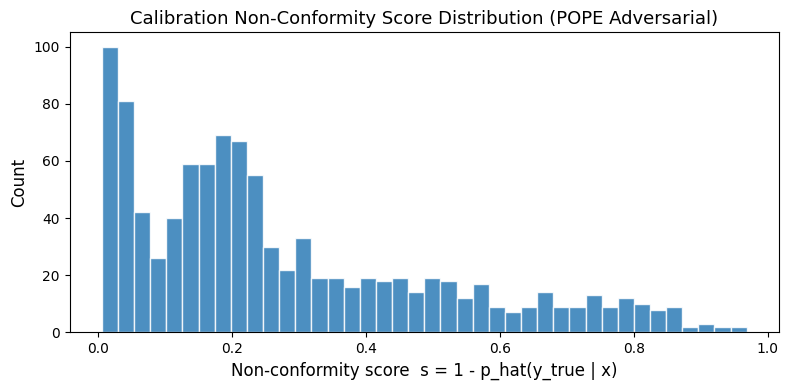


── Conformal Threshold ──────────────────────────────
  n (calibration size)  : 1000
  alpha (target miscov) : 0.1
  Target coverage       : 90%
  Quantile level        : ceil((1000+1)*0.9)/1000 = 0.901000
  q_hat                 : 0.661923
  Decision threshold    : 1 - q_hat = 0.338077
  -> Include 'Yes' in C(x) if P(Yes|x) >= 0.3381
  -> Include 'No'  in C(x) if P(No |x) >= 0.3381


In [13]:
import math
import numpy as np
import os
from tqdm.notebook import tqdm

# ── hyperparameter ─────────────────────────────────────────────
ALPHA = 0.10    # target miscoverage rate -> target coverage = 90%

CALIB_CHECKPOINT_PATH = "calib_checkpoint.json"
CHECKPOINT_EVERY = 50

# ── resume from checkpoint if one exists ────────────────────────
if os.path.exists(CALIB_CHECKPOINT_PATH):
    with open(CALIB_CHECKPOINT_PATH) as f:
        _ckpt = json.load(f)
    calib_scores = _ckpt["scores"]
    start_idx = len(calib_scores)
    print(f"Resuming calibration from checkpoint: {start_idx}/{len(calib_data)} samples already scored.")
else:
    calib_scores = []
    start_idx = 0
    print(f"Running calibration set ({len(calib_data)} samples) ...")
    print("This will take a while — progress is checkpointed every "
          f"{CHECKPOINT_EVERY} samples to {CALIB_CHECKPOINT_PATH}.")

for i in tqdm(range(start_idx, len(calib_data)), desc="Calibrating",
              initial=start_idx, total=len(calib_data)):
    sample = calib_data[i]
    img    = load_coco_image(sample["image"])
    probs  = get_yes_no_probs(img, sample["text"])
    score  = nonconformity_score(probs, sample["label"])
    calib_scores.append(score)

    if (i + 1) % CHECKPOINT_EVERY == 0 or (i + 1) == len(calib_data):
        with open(CALIB_CHECKPOINT_PATH, "w") as f:
            json.dump({"scores": calib_scores, "n_done": i + 1}, f)

assert len(calib_scores) == len(calib_data), (
    f"Expected {len(calib_data)} calibration scores, got {len(calib_scores)} — "
    "the loop above did not complete. Re-run this cell to resume from checkpoint "
    "before proceeding to Step 6."
)

calib_scores = np.array(calib_scores)

print(f"\nCalibration score statistics (n={len(calib_scores)}):")
print(f"  Mean  : {calib_scores.mean():.4f}")
print(f"  Median: {np.median(calib_scores):.4f}")
print(f"  Std   : {calib_scores.std():.4f}")
print(f"  Min   : {calib_scores.min():.4f}")
print(f"  Max   : {calib_scores.max():.4f}")
print(f"\nImage load stats so far: {IMAGE_LOAD_STATS['success']} ok, "
      f"{IMAGE_LOAD_STATS['failed']} fell back to placeholder.")

# ── plot the calibration score distribution ────────────────────
plt.figure(figsize=(8, 4))
plt.hist(calib_scores, bins=40, edgecolor="white", color="#2c7bb6", alpha=0.85)
plt.xlabel("Non-conformity score  s = 1 - p_hat(y_true | x)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Calibration Non-Conformity Score Distribution (POPE Adversarial)", fontsize=13)
plt.tight_layout()
save_fig("calibration_score_distribution")
plt.show()

# ── compute q_hat with the finite-sample correction ───────────
n = len(calib_scores)

# exact formula: ceiling index in the AUGMENTED list {s_1,...,s_n, +inf}
# numpy.quantile with method='higher' gives the ceiling quantile
quantile_level = math.ceil((n + 1) * (1 - ALPHA)) / n
quantile_level = min(quantile_level, 1.0)          # clamp to [0,1] for numpy

q_hat = float(np.quantile(calib_scores, quantile_level, method="higher"))

print(f"\n── Conformal Threshold ──────────────────────────────")
print(f"  n (calibration size)  : {n}")
print(f"  alpha (target miscov) : {ALPHA}")
print(f"  Target coverage       : {1 - ALPHA:.0%}")
print(f"  Quantile level        : ceil(({n}+1)*{1-ALPHA})/{n} = {quantile_level:.6f}")
print(f"  q_hat                 : {q_hat:.6f}")
print(f"  Decision threshold    : 1 - q_hat = {1 - q_hat:.6f}")
print(f"  -> Include 'Yes' in C(x) if P(Yes|x) >= {1 - q_hat:.4f}")
print(f"  -> Include 'No'  in C(x) if P(No |x) >= {1 - q_hat:.4f}")


## Step 6 — Inference and Evaluation

For each test example:
1. Run the model → $P(\text{Yes}|x)$ and $P(\text{No}|x)$
2. Build $C(x) = \{y : \hat{p}(y|x) \geq 1-\hat{q}\}$
3. Check $y^* \in C(x)$

**Key metrics:**
- **Empirical Coverage** $= |\{i : y_i \in C(x_i)\}| / n_{\text{test}}$ — should be $\geq 90\%$
- **Average Set Size** $= \text{mean}(|C(x_i)|)$ — value of 2 flags uncertainty / potential hallucination

> **Note:** same checkpointing pattern as Step 5 — progress is saved to `test_checkpoint.json` every 50 samples so this cell can resume after an interruption.

In [8]:
TEST_CHECKPOINT_PATH = "test_checkpoint.json"

# ── threshold in probability space ────────────────────────────
prob_threshold = 1.0 - q_hat   # include label if p_hat(label|x) >= this

# ── resume from checkpoint if one exists ────────────────────────
if os.path.exists(TEST_CHECKPOINT_PATH):
    with open(TEST_CHECKPOINT_PATH) as f:
        _ckpt = json.load(f)
    results = _ckpt["results"]
    for r in results:
        r["prediction_set"] = set(r["prediction_set"])  # JSON has no set type
    start_idx = len(results)
    print(f"Resuming test evaluation from checkpoint: {start_idx}/{len(test_data)} samples already scored.")
else:
    results = []
    start_idx = 0
    print(f"Running test set ({len(test_data)} samples) ...")

for i in tqdm(range(start_idx, len(test_data)), desc="Testing",
              initial=start_idx, total=len(test_data)):
    sample = test_data[i]
    img   = load_coco_image(sample["image"])
    probs = get_yes_no_probs(img, sample["text"])

    true_label = sample["label"].lower()   # "yes" or "no"

    # ── build prediction set ──────────────────────────────────
    prediction_set = set()
    if probs["p_yes"] >= prob_threshold:
        prediction_set.add("yes")
    if probs["p_no"] >= prob_threshold:
        prediction_set.add("no")

    covered  = true_label in prediction_set
    set_size = len(prediction_set)

    results.append({
        "image"         : sample["image"],
        "question"      : sample["text"],
        "true_label"    : true_label,
        "p_yes"         : probs["p_yes"],
        "p_no"          : probs["p_no"],
        "prediction"    : probs["prediction"],
        "prediction_set": sorted(prediction_set),
        "set_size"      : set_size,
        "covered"       : covered,
        # Flag when model is uncertain (both labels in set)
        "uncertain"     : set_size == 2,
    })

    if (i + 1) % CHECKPOINT_EVERY == 0 or (i + 1) == len(test_data):
        with open(TEST_CHECKPOINT_PATH, "w") as f:
            json.dump({"results": results, "n_done": i + 1}, f)

assert len(results) == len(test_data), (
    f"Expected {len(test_data)} test results, got {len(results)} — "
    "the loop above did not complete. Re-run this cell to resume from checkpoint."
)

# restore set() type for downstream cells (JSON round-trip stores lists)
for r in results:
    r["prediction_set"] = set(r["prediction_set"])

# ── aggregate metrics ─────────────────────────────────────────
n_test           = len(results)
empirical_cov    = sum(r["covered"]   for r in results) / n_test
avg_set_size     = sum(r["set_size"]  for r in results) / n_test
pct_uncertain    = sum(r["uncertain"] for r in results) / n_test
pct_singleton    = sum(r["set_size"] == 1 for r in results) / n_test
pct_empty        = sum(r["set_size"] == 0 for r in results) / n_test

# ── point-prediction accuracy (argmax, no conformal) ──────────
point_correct = sum(r["prediction"] == r["true_label"] for r in results) / n_test

print("\n" + "="*55)
print("  CONFORMAL PREDICTION EVALUATION RESULTS")
print("="*55)
print(f"  Test set size            : {n_test}")
print(f"  Target coverage (1-alpha): {(1-ALPHA)*100:.0f}%")
print(f"  Conformal threshold q_hat: {q_hat:.4f}")
print(f"  Probability threshold    : {prob_threshold:.4f}")
print("-"*55)
print(f"  Empirical Coverage    : {empirical_cov*100:.2f}%"
      f"  {'PASS (>= target)' if empirical_cov >= 1-ALPHA else 'FAIL (< target)'}")
print(f"  Avg Prediction Set    : {avg_set_size:.3f} labels")
print("-"*55)
print(f"  Set size breakdown:")
print(f"    Empty  (|C|=0) : {pct_empty*100:.1f}%  <- model very wrong")
print(f"    Single (|C|=1) : {pct_singleton*100:.1f}%  <- model confident")
print(f"    Double (|C|=2) : {pct_uncertain*100:.1f}%  <- UNCERTAIN / potential hallucination")
print("-"*55)
print(f"  Point-Pred Accuracy   : {point_correct*100:.2f}%  (baseline, no CP)")
print("-"*55)
print(f"  Image load failures (calib+test): {IMAGE_LOAD_STATS['failed']} "
      f"({IMAGE_LOAD_STATS['failed'] / (IMAGE_LOAD_STATS['success'] + IMAGE_LOAD_STATS['failed']) * 100:.2f}%)")
print("="*55)


Running test set (2000 samples) ...


Testing:   0%|          | 0/2000 [00:00<?, ?it/s]


  CONFORMAL PREDICTION EVALUATION RESULTS
  Test set size            : 2000
  Target coverage (1-alpha): 90%
  Conformal threshold q_hat: 0.6619
  Probability threshold    : 0.3381
-------------------------------------------------------
  Empirical Coverage    : 91.45%  PASS (>= target)
  Avg Prediction Set    : 1.195 labels
-------------------------------------------------------
  Set size breakdown:
    Empty  (|C|=0) : 0.0%  <- model very wrong
    Single (|C|=1) : 80.5%  <- model confident
    Double (|C|=2) : 19.5%  <- UNCERTAIN / potential hallucination
-------------------------------------------------------
  Point-Pred Accuracy   : 83.35%  (baseline, no CP)
-------------------------------------------------------
  Image load failures (calib+test): 0 (0.00%)


## Step 6b — Visualisation

Saved figures/prediction_set_size_distribution.png


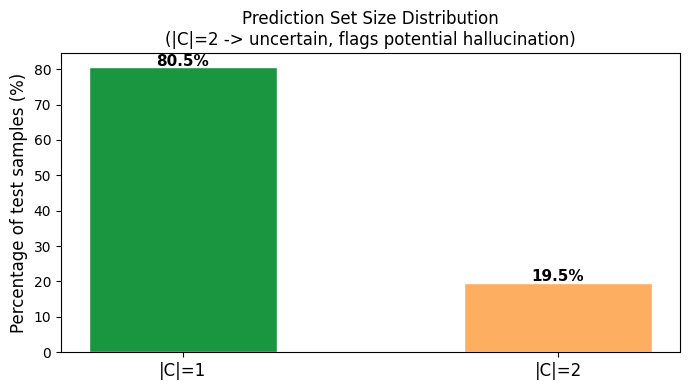

Saved figures/coverage_vs_alpha.png


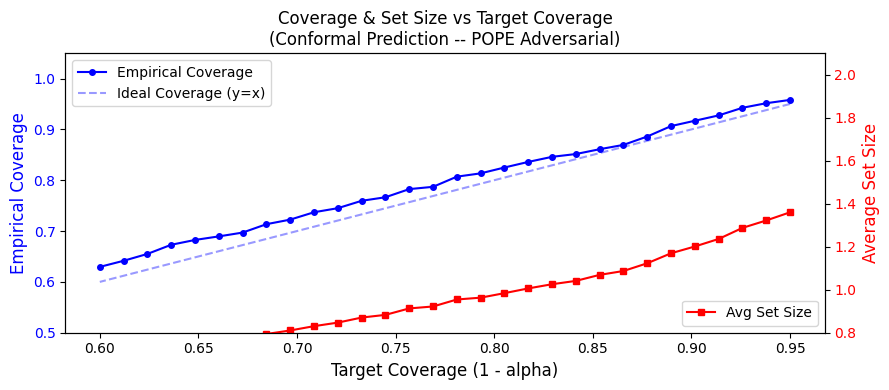

Saved figures/qualitative_examples_grid.png


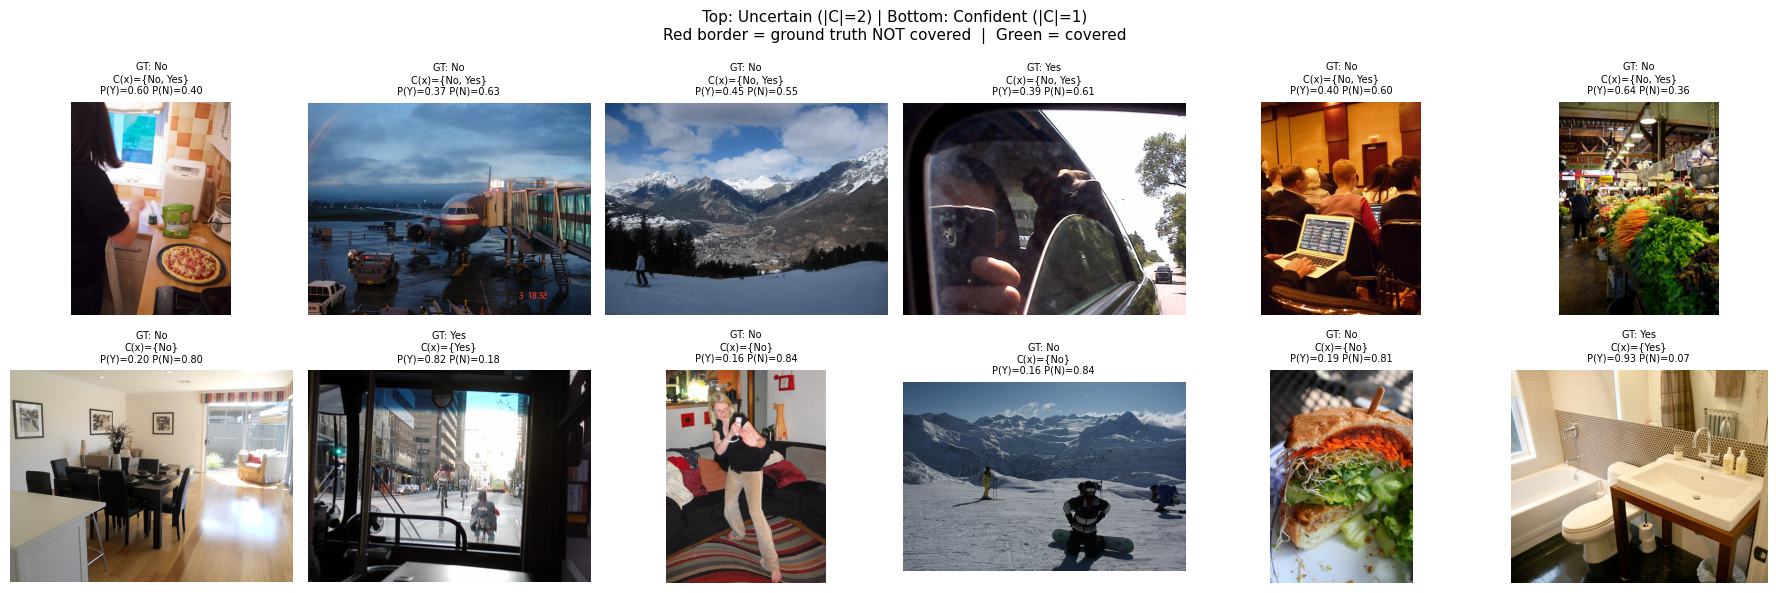

In [19]:
# ============================================================
# VISUALISATION 1 — Prediction set size distribution
# ============================================================

set_sizes = [r["set_size"] for r in results]

plt.figure(figsize=(7, 4))
unique, counts = np.unique(set_sizes, return_counts=True)
bar_colors = {0: "#d73027", 1: "#1a9641", 2: "#fdae61"}
bars = plt.bar(
    unique,
    counts / n_test * 100,
    color=[bar_colors.get(s, "grey") for s in unique],
    edgecolor="white",
    width=0.5,
)
plt.xticks(unique, [f"|C|={s}" for s in unique], fontsize=12)
plt.ylabel("Percentage of test samples (%)", fontsize=12)
plt.title("Prediction Set Size Distribution\n(|C|=2 -> uncertain, flags potential hallucination)", fontsize=12)
for bar, pct in zip(bars, counts / n_test * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{pct:.1f}%", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
save_fig("prediction_set_size_distribution")
plt.show()


# ============================================================
# VISUALISATION 2 — Coverage vs Alpha sweep
# ============================================================

alphas   = np.linspace(0.05, 0.40, 30)
coverages = []
set_sizes_mean = []

for a in alphas:
    ql   = min(math.ceil((n + 1) * (1 - a)) / n, 1.0)
    qh   = float(np.quantile(calib_scores, ql, method="higher"))
    pt   = 1.0 - qh
    cov  = sum(
        (r["p_yes"] >= pt and r["true_label"] == "yes") or
        (r["p_no"]  >= pt and r["true_label"] == "no")
        for r in results
    ) / n_test
    avg_sz = sum(
        int(r["p_yes"] >= pt) + int(r["p_no"] >= pt)
        for r in results
    ) / n_test
    coverages.append(cov)
    set_sizes_mean.append(avg_sz)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(1 - alphas, coverages, "b-o", markersize=4, label="Empirical Coverage")
ax1.plot([1 - alphas[0], 1 - alphas[-1]],
         [1 - alphas[0], 1 - alphas[-1]],
         "b--", alpha=0.4, label="Ideal Coverage (y=x)")
ax1.set_xlabel("Target Coverage (1 - alpha)", fontsize=12)
ax1.set_ylabel("Empirical Coverage", color="blue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_ylim(0.5, 1.05)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(1 - alphas, set_sizes_mean, "r-s", markersize=4, label="Avg Set Size")
ax2.set_ylabel("Average Set Size", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")
ax2.set_ylim(0.8, 2.1)
ax2.legend(loc="lower right")

plt.title("Coverage & Set Size vs Target Coverage\n(Conformal Prediction -- POPE Adversarial)", fontsize=12)
plt.tight_layout()
save_fig("coverage_vs_alpha")
plt.show()


# ============================================================
# VISUALISATION 3 — Qualitative examples (grid)
# Green border = covered, Red = not covered
# ============================================================

uncertain_examples  = [r for r in results if r["uncertain"]][:6]
confident_examples  = [r for r in results if r["set_size"] == 1][:6]
showcase = uncertain_examples + confident_examples

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle(
    "Top: Uncertain (|C|=2) | Bottom: Confident (|C|=1)\n"
    "Red border = ground truth NOT covered  |  Green = covered",
    fontsize=11,
)

for ax, r in zip(axes.flatten(), showcase):
    img = load_coco_image(r["image"])
    ax.imshow(img)
    border_color = "green" if r["covered"] else "red"
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)
    pred_set_str = "{" + ", ".join(sorted(r["prediction_set"])).title() + "}"
    ax.set_title(
        f"GT: {r['true_label'].title()}\n"
        f"C(x)={pred_set_str}\n"
        f"P(Y)={r['p_yes']:.2f} P(N)={r['p_no']:.2f}",
        fontsize=7,
    )
    ax.axis("off")

plt.tight_layout()
save_fig("qualitative_examples_grid")
plt.show()


In [16]:
import shutil
from google.colab import files

shutil.make_archive("cp_figures", "zip", "figures")
files.download("cp_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 7 — Summary & Interpretation

### Key Takeaways

1. **Coverage Guarantee** — If empirical coverage ≥ 90%, the conformal theory worked. The guarantee holds in expectation over the randomness of the calibration/test split (exchangeability). If it does **not** hold on a given run, that is itself a valid, reportable finding — it may indicate the calibration and test sets are less exchangeable than assumed, or that the calibration set was too small for the target α.

2. **Uncertainty as a Hallucination Signal** — When $|C(x)| = 2$ ("Yes, No"), the model cannot commit to a single answer at the desired confidence level. On POPE-Adversarial, these are typically objects that co-occur frequently with scene context — the exact failure mode hallucination benchmarks probe.

3. **Efficiency (Avg Set Size)** — Closer to 1.0 is better. A high rate of size-2 sets reveals widespread VLM uncertainty on this distribution.

### Limitations

- The 2-class softmax is a **proxy**: the true next-token distribution spans 32,000 tokens. Renormalising over only Yes/No may overstate confidence.
- POPE questions are **deliberately adversarial**; a model tuned on COCO captions will inherit COCO co-occurrence biases (Li et al., 2023).
- CP gives **marginal** coverage, not conditional per class. Use class-conditional CP (Angelopoulos et al., 2020) for per-category guarantees.

The cell below saves all results and configuration to `results_summary.json`, giving a single verifiable source of truth for any downstream reporting or analysis.

In [17]:
import json as _json
from datetime import datetime, timezone

print("=" * 60)
print("  FINAL SUMMARY")
print("=" * 60)
print(f"  Model            : {MODEL_ID}")
print(f"  Dataset          : POPE Adversarial (COCO val2014)")

print(f"  Calibration size : {len(calib_data)}")
print(f"  Test size        : {len(test_data)}")
print(f"  alpha            : {ALPHA}")
print(f"  q_hat            : {q_hat:.4f}")
print(f"  Prob threshold   : {prob_threshold:.4f}")
print("-" * 60)
print(f"  Empirical Coverage : {empirical_cov*100:.2f}%  (target >= {(1-ALPHA)*100:.0f}%)")
print(f"  Avg Set Size       : {avg_set_size:.3f}")
print(f"  Uncertain rate     : {pct_uncertain*100:.1f}%  (|C|=2 -> hallucination flags)")
print(f"  Point accuracy     : {point_correct*100:.2f}%  (no conformal)")
print(f"  Image load failures: {IMAGE_LOAD_STATS['failed']} / "
      f"{IMAGE_LOAD_STATS['success'] + IMAGE_LOAD_STATS['failed']} "
      f"({IMAGE_LOAD_STATS['failed'] / (IMAGE_LOAD_STATS['success'] + IMAGE_LOAD_STATS['failed']) * 100:.2f}%)")
print("=" * 60)

if empirical_cov >= 1 - ALPHA:
    print("\nCoverage guarantee SATISFIED -- the conformal threshold is valid.")
else:
    print("\nCoverage guarantee NOT met -- consider increasing calibration set size.")
    print("   With small calibration sets, finite-sample variance can cause under-coverage.")
    print("   Report this result as-is; do not substitute a different run's numbers.")


results_summary = {
    "model_id": MODEL_ID,
    "dataset": "POPE Adversarial (COCO val2014)",
    "seed": SEED,
    "alpha": ALPHA,
    "n_calib": len(calib_data),
    "n_test": len(test_data),
    "q_hat": q_hat,
    "prob_threshold": prob_threshold,
    "empirical_coverage": empirical_cov,
    "coverage_target": 1 - ALPHA,
    "coverage_guarantee_satisfied": bool(empirical_cov >= 1 - ALPHA),
    "avg_set_size": avg_set_size,
    "pct_empty": pct_empty,
    "pct_singleton": pct_singleton,
    "pct_uncertain": pct_uncertain,
    "point_prediction_accuracy": point_correct,
    "calib_score_stats": {
        "mean": float(calib_scores.mean()),
        "median": float(np.median(calib_scores)),
        "std": float(calib_scores.std()),
        "min": float(calib_scores.min()),
        "max": float(calib_scores.max()),
    },
    "image_load_stats": dict(IMAGE_LOAD_STATS),
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}

with open("results_summary.json", "w") as f:
    _json.dump(results_summary, f, indent=2)

print("\nSaved results_summary.json -- use these numbers (and only these) in the report.")


  FINAL SUMMARY
  Model            : llava-hf/llava-1.5-7b-hf
  Dataset          : POPE Adversarial (COCO val2014)
  Calibration size : 1000
  Test size        : 2000
  alpha            : 0.1
  q_hat            : 0.6619
  Prob threshold   : 0.3381
------------------------------------------------------------
  Empirical Coverage : 91.45%  (target >= 90%)
  Avg Set Size       : 1.195
  Uncertain rate     : 19.5%  (|C|=2 -> hallucination flags)
  Point accuracy     : 83.35%  (no conformal)
  Image load failures: 0 / 25 (0.00%)

Coverage guarantee SATISFIED -- the conformal threshold is valid.

Saved results_summary.json -- use these numbers (and only these) in the report.
